In [12]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [13]:
class AgentState(TypedDict):
    number_one: float
    number_two: float
    number_three: float
    number_four: float
    operator_one: str
    operator_two: str
    final_result_one: float
    final_result_two: float

In [14]:
def addition_node_one(state: AgentState) -> AgentState:
    """This node adds the two numbers"""
    state["final_result_one"] = state["number_one"] + state["number_two"]
    return state

In [15]:
def subtraction_node_one(state: AgentState) -> AgentState:
    """This node subtract the two numbers"""
    state["final_result_one"] = state["number_one"] - state["number_two"]
    return state

In [16]:
def operator_node_one(state: AgentState) -> AgentState:
    """This node select the next phase"""
    if state["operator_one"] == "+":
        return "addition_operation_one"
    elif state["operator_one"] == "-":
        return "subtraction_operation_one"

In [17]:
def addition_node_two(state: AgentState) -> AgentState:
    """This node adds the two numbers"""
    state["final_result_two"] = state["number_three"] + state["number_four"]
    return state

In [18]:
def subtraction_node_two(state: AgentState) -> AgentState:
    """This node subtract the two numbers"""
    state["final_result_two"] = state["number_three"] - state["number_four"]
    return state

In [19]:
def operator_node_two(state: AgentState) -> AgentState:
    """This node select the next phase"""
    if state["operator_two"] == "+":
        return "addition_operation_two"
    elif state["operator_two"] == "-":
        return "subtraction_operation_two"

In [20]:
graph = StateGraph(AgentState)
graph.add_node("addition_one", addition_node_one)
graph.add_node("subtraction_one", subtraction_node_one)
graph.add_node("route_one", lambda state: state)

graph.add_node("addition_two", addition_node_two)
graph.add_node("subtraction_two", subtraction_node_two)
graph.add_node("route_two", lambda state: state)

graph.add_edge(START, "route_one")
graph.add_conditional_edges(
    "route_one",
    operator_node_one,
    {
        "addition_operation_one": "addition_one",
        "subtraction_operation_one": "subtraction_one"
    }
)
graph.add_edge("addition_one", "route_two")
graph.add_edge("subtraction_one", "route_two")

graph.add_conditional_edges(
    "route_two",
    operator_node_two,
    {
        "addition_operation_two": "addition_two",
        "subtraction_operation_two": "subtraction_two"
    }
)

graph.add_edge("addition_two", END)
graph.add_edge("subtraction_two", END)

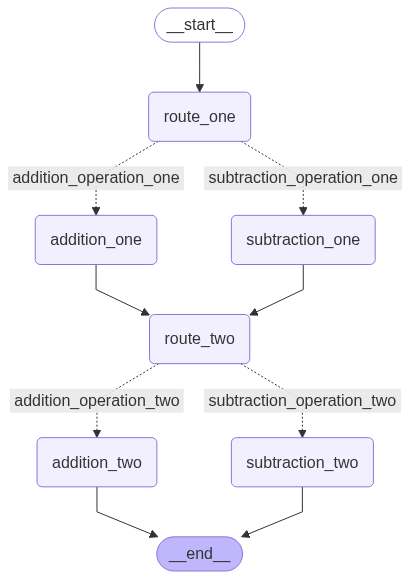

In [21]:
app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [22]:
result = app.invoke({"number_one" : 10, "number_two" : 5, "operator_one" : "-", "number_three" : 10, "number_four" : 5, "operator_two" : "+"})
print(result)

{'number_one': 10, 'number_two': 5, 'number_three': 10, 'number_four': 5, 'operator_one': '-', 'operator_two': '+', 'final_result_one': 5, 'final_result_two': 15}
